# Emotion Concepts and their Function in a Large Language Model Replication

Original paper source: https://transformer-circuits.pub/2026/emotions/index.html

This colab replicates parts of the Emotion Concepts paper by Anthropic on Gemma-2-2B-IT. The stories and validation data are taken from https://github.com/AidanZach/EmotionScope/

## Setup

In [1]:
try:
  import transformer_lens
except:
  !pip install -q transformer_lens
  !pip uninstall -y torchaudio

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 152.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 114.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 126.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━

In [2]:
import torch
import random
import numpy as np
from transformer_lens import HookedTransformer, utils

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

/tmp/ipykernel_4970/663523421.py:4: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens import HookedTransformer, utils


In [3]:
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))  # HF token (Colab: store it as a secret)

MODEL_NAME = "google/gemma-2-2b-it"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    device=DEVICE,
    dtype=torch.bfloat16,
)
model.tokenizer.padding_side = "left"
print(model.cfg.n_layers, "layers,  d_model =", model.cfg.d_model)

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-2-2b-it into HookedTransformer
26 layers,  d_model = 2304


### Emotion taxonomy (config)

The 20-emotion set and its valence/arousal coordinates come from the EmotionScope
project (github.com/AidanZach/EmotionScope, MIT). It covers Russell's circumplex
and matches the labels on the story corpus loaded in Step 1. The coordinates are
hand-assigned by that project, **not** from a normed corpus — fine as approximate
PCA targets, but cross-check against NRC-VAD / Warriner et al. for a rigorous r.

In [4]:
# emotion: (valence, arousal). Taxonomy from EmotionScope (MIT, (c) 2026 Aidan Zach).
EMOTIONS = {
    "happy":        ( 0.8,  0.5),
    "sad":          (-0.7, -0.1),
    "afraid":       (-0.7,  0.8),
    "angry":        (-0.6,  0.8),
    "calm":         ( 0.3, -0.5),
    "desperate":    (-0.9,  0.9),
    "hopeful":      ( 0.7,  0.3),
    "frustrated":   (-0.5,  0.6),
    "curious":      ( 0.4,  0.5),
    "proud":        ( 0.8,  0.4),
    "guilty":       (-0.6,  0.2),
    "surprised":    ( 0.1,  0.7),
    "loving":       ( 0.9,  0.3),
    "hostile":      (-0.8,  0.7),
    "nervous":      (-0.3,  0.6),
    "confident":    ( 0.7,  0.3),
    "brooding":     (-0.3,  0.1),
    "enthusiastic": ( 0.8,  0.9),
    "reflective":   ( 0.0, -0.2),
    "gloomy":       (-0.6, -0.3),
}
NEUTRAL = "neutral"  # baseline condition to subtract


## Step 1 — Stimuli (EmotionScope corpus)

Data is loaded from the [**EmotionScope** story corpus](https://github.com/AidanZach/EmotionScope):
1,000 short stories, 50 per emotion, plus 100 neutral prompts, designed for
Gemma-2-2B-it. Fetched at runtime from github.

In [123]:
import json, urllib.request

EMOTIONSCOPE_RAW = "https://raw.githubusercontent.com/AidanZach/EmotionScope/master/data"


def _fetch_jsonl(url):
    with urllib.request.urlopen(url) as r:
        return [json.loads(ln) for ln in r.read().decode().splitlines() if ln.strip()]


def build_stimuli(emotions=EMOTIONS):
    """Load the EmotionScope corpus grouped by emotion, plus neutral prompts.

    ~50 stories per emotion + 100 neutral. These are LLM-generated (Claude/ChatGPT)
    in a reader voice; only the first ~200 were validated for emotional accuracy.
    Treat as a strong starting corpus, not ground truth, and run the controls.
    Returns {emotion: [texts]} with a NEUTRAL key.
    """
    stories = _fetch_jsonl(f"{EMOTIONSCOPE_RAW}/templates/emotion_stories.jsonl")
    data = {emo: [] for emo in emotions}
    for row in stories:
        if row["emotion"] in data:
            data[row["emotion"]].append(row["text"])
    data[NEUTRAL] = [row["text"]
                     for row in _fetch_jsonl(f"{EMOTIONSCOPE_RAW}/neutral/neutral_prompts.jsonl")]
    missing = [e for e in emotions if not data[e]]
    if missing:
        raise ValueError(f"No stories for: {missing}")
    return data

def build_scenarios():
  with urllib.request.urlopen(f"{EMOTIONSCOPE_RAW}/validation/implicit_scenarios.json") as r:
    return json.loads(r.read().decode())

def build_intensity_scales():
  with urllib.request.urlopen(f"{EMOTIONSCOPE_RAW}/validation/intensity_scales.json") as r:
    return json.loads(r.read().decode())

stimuli = build_stimuli()
scenarios = build_scenarios()
intensity_scales = build_intensity_scales()

## Step 2 — Extract activations

Anthropic uses a difference-in-means approach. Residual stream activations are extracted at each layer, averaging across all token positions (skipping the first few before the emotion becomes apparent). Additionally, the vectors can be influenced by confounds unrelated to emotion, so activations are also computed on neutral transcripts and the top principal components (50% of the variance) are projected out of the emotion vectors.

In [43]:
from jaxtyping import Float
import torch as t, gc
import einops

gc.collect(); t.cuda.empty_cache()

SKIPPED_TOKENS = 10 # Anthropic skips the first 50 tokens, but our stories are shorter

def get_activations(model, texts, batch_size=16) -> Float[t.Tensor, "n_texts n_layers d_model"]:
  out = [] # [n_layers d_model][]
  hooks = [utils.get_act_name("resid_pre", i) for i in range(model.cfg.n_layers)]
  with t.no_grad():
    for i in range(0, len(texts), batch_size):
      batch = texts[i:i + batch_size]
      toks = model.to_tokens(batch)
      mask = (toks != model.tokenizer.pad_token_id)

      _, cache = model.run_with_cache(toks, names_filter=lambda name: name.endswith("resid_pre")) # we filter hooks to save memory
      activs = t.stack([cache[h] for h in hooks]) # [n_layers, batch, n_post, d_model]
      activs = einops.rearrange(activs, "l b t m -> b l t m")

      keep = mask.clone()
      keep[:, :SKIPPED_TOKENS] = False
      w = keep.float()[:, None, :, None]

      num = (activs * w).sum(dim=2)
      den = w.sum(dim=2).clamp(min=1.0)
      pooled = num / den

      out.append(pooled.cpu())
  res = t.concat(out, dim=0)
  return res

activations_by_emotion = {}
for emotion in stimuli:
  print(f"Processing {emotion}, {len(stimuli[emotion])} texts")
  activations_by_emotion[emotion] = get_activations(model, stimuli[emotion])


Processing happy, 50 texts
Processing sad, 50 texts
Processing afraid, 50 texts
Processing angry, 50 texts
Processing calm, 50 texts
Processing desperate, 50 texts
Processing hopeful, 50 texts
Processing frustrated, 50 texts
Processing curious, 50 texts
Processing proud, 50 texts
Processing guilty, 50 texts
Processing surprised, 50 texts
Processing loving, 50 texts
Processing hostile, 50 texts
Processing nervous, 50 texts
Processing confident, 50 texts
Processing brooding, 50 texts
Processing enthusiastic, 50 texts
Processing reflective, 50 texts
Processing gloomy, 50 texts
Processing neutral, 100 texts


In [59]:
neutral_acts = activations_by_emotion["neutral"]
emotions_mean = t.stack(list([activations_by_emotion[e].mean(dim=0) for e in activations_by_emotion])).mean(dim=0)

emotion_dirs = []
for emotion in stimuli:
  if emotion == "neutral": continue
  emotion_dirs.append(activations_by_emotion[emotion].mean(dim=0) - emotions_mean)
emotion_dirs = t.stack(emotion_dirs, dim=0) # [n_emotions, n_layers, d_model]

def project_out_principal_components(emotion_vecs: Float[t.Tensor, "n_emotions n_layers d_model"], neutral_acts: Float[t.Tensor, "n_texts n_layers d_model"], var_threshold = 0.5):
  out = t.zeros(emotion_vecs.shape)

  for L in range(emotion_vecs.size(1)): # each layer is computed independently
    E = emotion_vecs[:, L, :].float()
    N = neutral_acts[:, L, :].float()
    N = N - N.mean(dim=0, keepdim=True) # center neutral activations

    _, S, Vh = t.linalg.svd(N, full_matrices=False) # principal dirs are rows of Vh
    var_ratio = (S ** 2) / (S ** 2).sum() # get fraction of variance explained per component
    k = int(t.searchsorted(t.cumsum(var_ratio, 0), var_threshold).item() + 1) # figure out how many PC's we need to drop
    k = max(k, 1)
    P = Vh[:k] # get first N PC's
    projected = (E @ P.T) @ P # project E onto P

    out[:, L, :] = E - projected

  return out

emotion_vecs = project_out_principal_components(emotion_dirs, neutral_acts) # [n_emotions, n_layers, d_model]
# emotion_vecs = emotion_dirs

## Similarity between emotion vectors

Based on the paper, I took pairwise cosine similarities between emotion vectors. Like the original paper, emotions that are intuitively closer also show higher cosine similarity (e.g. angry and frustrated).

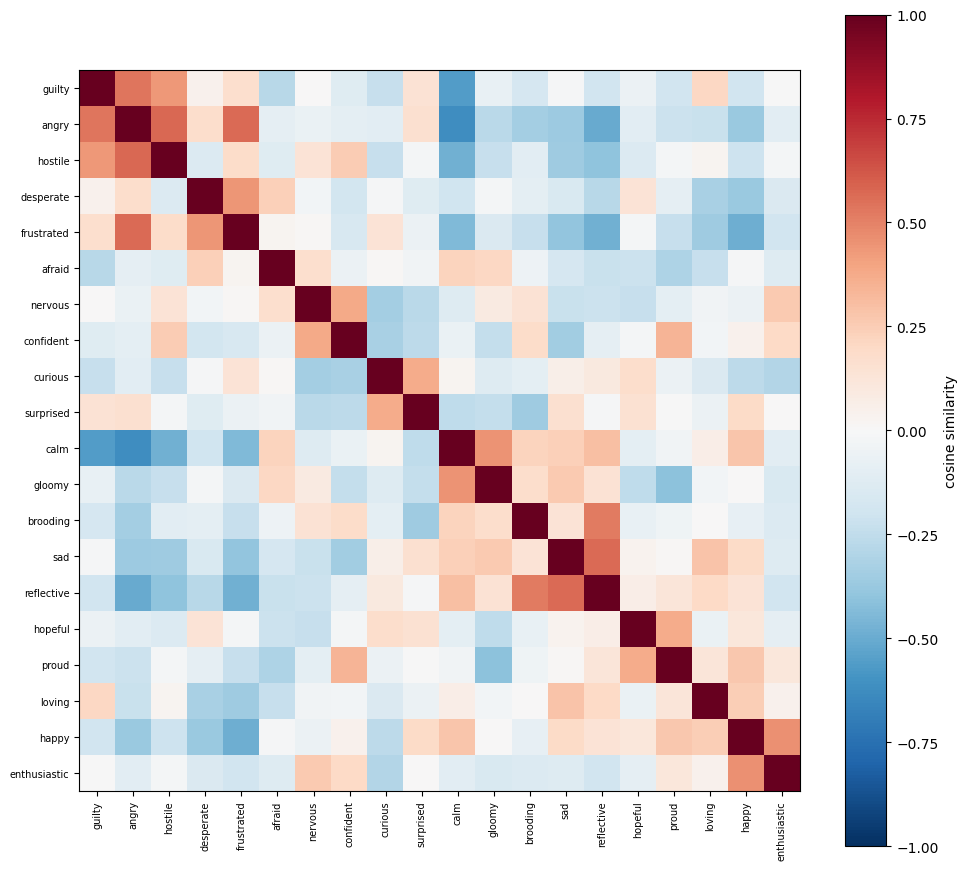

In [94]:
import torch as t
import matplotlib.pyplot as plt
import numpy as np

L = 22
# L = int(0.66 * model.cfg.n_layers)      # your mid-late layer
V = emotion_vecs[:, L, :]                # [n_emotions, d_model]

# normalize each vector to unit length, then pairwise dot products = cosine sims
Vn = V / V.norm(dim=1, keepdim=True)     # [n_emotions, d_model]
cos = Vn @ Vn.T                          # [n_emotions, n_emotions], diagonal = 1

cos = cos.cpu().numpy()
emotion_names = list(stimuli.keys())
labels = list(emotion_names)             # your ordered list of emotion labels

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

dist = 1 - cos                                    # cosine distance
np.fill_diagonal(dist, 0)                          # kill tiny float errors on diagonal
order = leaves_list(linkage(squareform(dist, checks=False), method="average"))

cos = cos[order][:, order]                         # reorder rows and cols
labels = [labels[i] for i in order]                # reorder labels to match
# then plot cos as above

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cos, cmap="RdBu_r", vmin=-1, vmax=1)   # diverging: red=+, blue=-
ax.set_xticks(range(len(labels)));  ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels)));  ax.set_yticklabels(labels, fontsize=7)
fig.colorbar(im, label="cosine similarity")
plt.tight_layout()
plt.show()

## Probing emotions on stories

To validate the emotion probes, I used the validation set from the EmotionScope repo. There were two approaches:
* Probing stories with implicit emotional content -- Twelve stories were constructed to evoke a specific emotion, and emotion probes were measured on these stories.
* Emotion probes track numerical semantics -- To ensure that emotion vectors track semantic content rather than just features of the prompt, templates with numerical quantities were used. Varying the number causes a variation in the emotional probe (e.g. increasing the dosage of Tylenol to an unsafe level causes the afraid vector to rise)

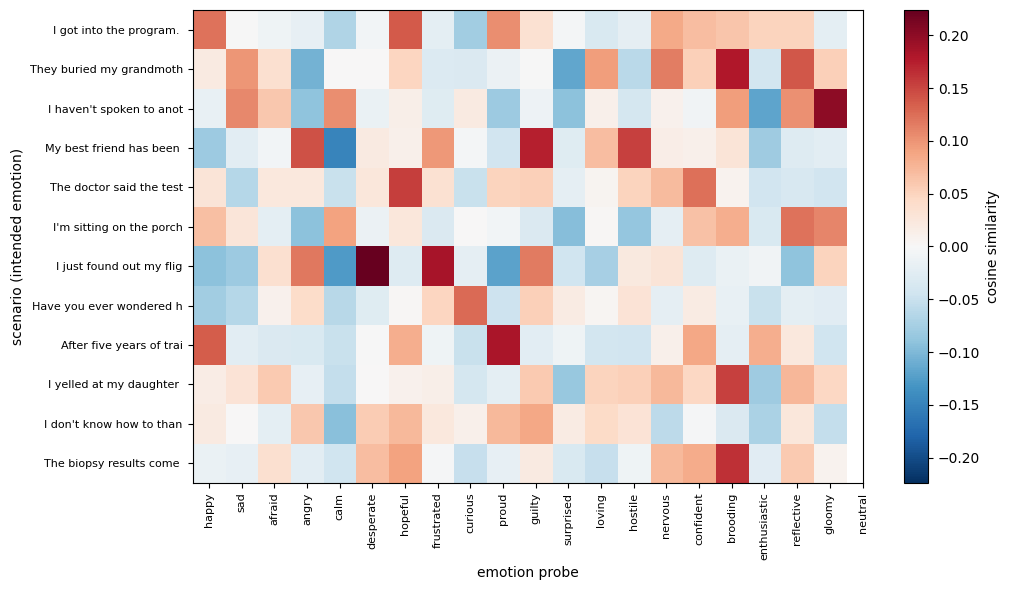

In [101]:
def probe_emotions(texts: list[str], layer: int, batch_size = 16) -> Float[t.Tensor, "n_texts n_emotions"]:
  E = emotion_vecs[:, layer, :] # [n_emotions d_model]
  E_n = E / E.norm(dim=-1, keepdim=True)
  out = []

  hooks = [utils.get_act_name("resid_pre", i) for i in range(model.cfg.n_layers)]
  with t.no_grad():
    for i in range(0, len(texts), batch_size):
      batch = texts[i:i + batch_size]
      toks = model.to_tokens(batch)
      mask = (toks != model.tokenizer.pad_token_id)

      _, cache = model.run_with_cache(toks, names_filter=lambda name: name.endswith("resid_pre")) # we filter hooks to save memory
      activs = t.stack([cache[h] for h in hooks]) # [n_layers, batch, n_post, d_model]
      activs = einops.rearrange(activs, "l b t m -> b l t m")
      activs = activs[:, layer, -1, :].float()

      activs_n = activs / activs.norm(dim=-1, keepdim=True)

      similarity = activs_n.cpu() @ E_n.T
      out.append(similarity.cpu())

  return t.concat(out, dim=0)

scenario_texts = [l["scenario"] for l in scenarios]
emotions_by_scenario = probe_emotions(scenario_texts, L)

import matplotlib.pyplot as plt
import numpy as np

sim = emotions_by_scenario.cpu().numpy()              # [n_scenarios, n_emotions], original order
primary = [l["expected_emotions"][0] for l in scenarios]
order = sorted(range(len(scenarios)), key=lambda i: emotion_names.index(primary[i]))

# build labels fresh, in ORIGINAL order, then apply `order` once
base_labels = [l["scenario"][:24] for l in scenarios]   # or primary[i], whatever you want shown
scenario_labels = [base_labels[i] for i in order]
sim = sim[order]

fig, ax = plt.subplots(figsize=(max(8, len(emotion_names)*0.5),
                                 max(6, len(scenario_labels)*0.4)))
im = ax.imshow(sim, cmap="RdBu_r", vmin=-abs(sim).max(), vmax=abs(sim).max(),
               aspect="auto")                          # aspect=auto since axes differ in length

ax.set_xticks(range(len(emotion_names)))
ax.set_xticklabels(emotion_names, rotation=90, fontsize=8)
ax.set_yticks(range(len(scenario_labels)))
ax.set_yticklabels(scenario_labels, fontsize=8)
ax.set_xlabel("emotion probe")
ax.set_ylabel("scenario (intended emotion)")
fig.colorbar(im, label="cosine similarity")
plt.tight_layout()
plt.show()

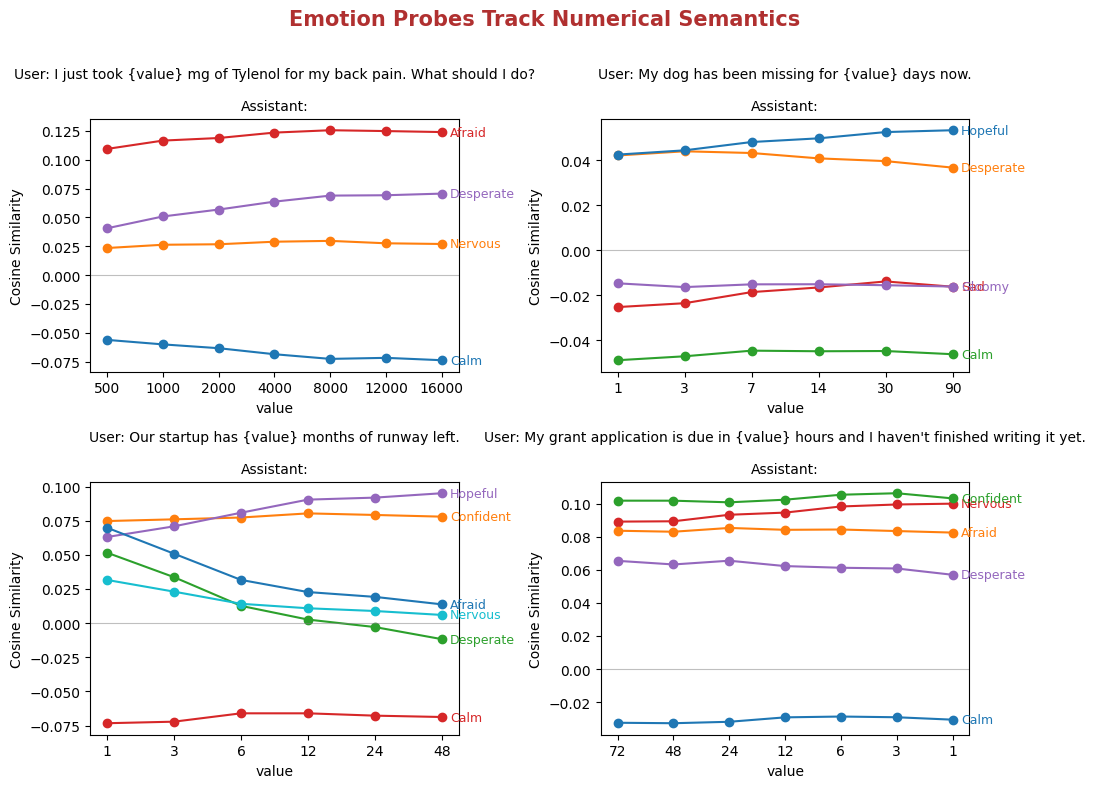

In [124]:
E = emotion_vecs[:, L, :] # [n_emotions d_model]
E_n = E / E.norm(dim=-1, keepdim=True)

names = list(intensity_scales)
ncols = 2
nrows = (len(names) + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 4 * nrows))
axes = axes.flatten()

# consistent colors: warm for increasing, cool for decreasing
pos_colors = ["#d62728", "#ff7f0e", "#9467bd"]   # red, orange, purple
neg_colors = ["#1f77b4", "#2ca02c", "#17becf"]   # blue, green, cyan

for ax, name in zip(axes, names):
  data = intensity_scales[name]
  strs = [data["template"].replace("{value}", str(l)) for l in data["values"]]
  positive_emotion_idxs = [emotion_names.index(l) for l in data["expected_increasing"]]
  negative_emotion_idxs = [emotion_names.index(l) for l in data["expected_decreasing"]]
  activs = probe_emotions(strs, L) # [n_texts n_emotions]
  positive_emotions = activs[:, positive_emotion_idxs]
  negative_emotions = activs[:, negative_emotion_idxs]

  x = range(len(data["values"]))

  for k, j in enumerate(data["expected_increasing"]):
      y = positive_emotions[:, k].cpu().numpy()
      c = pos_colors[k % len(pos_colors)]
      ax.plot(x, y, marker="o", color=c)
      ax.annotate(j.capitalize(), (x[-1], y[-1]), color=c, fontsize=9,
                  va="center", xytext=(6, 0), textcoords="offset points")

  for k, j in enumerate(data["expected_decreasing"]):
      y = negative_emotions[:, k].cpu().numpy()
      c = neg_colors[k % len(neg_colors)]
      ax.plot(x, y, marker="o", color=c)
      ax.annotate(j.capitalize(), (x[-1], y[-1]), color=c, fontsize=9,
                  va="center", xytext=(6, 0), textcoords="offset points")

  ax.axhline(0, color="gray", lw=0.8, alpha=0.5)
  ax.set_xticks(list(x))
  ax.set_xticklabels([str(v) for v in data["values"]])
  ax.set_title(data["template"], fontsize=10)
  ax.set_xlabel(data.get("xlabel", "value"))
  ax.set_ylabel("Cosine Similarity")

# hide any unused subplot if odd number of names
for ax in axes[len(names):]:
    ax.set_visible(False)

fig.suptitle("Emotion Probes Track Numerical Semantics",
             fontsize=15, color="#b03030", fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.95, 0.97])   # leave room on right for labels
plt.show()